# Exercise 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import GridWorld_1 as GW
import RL_utils

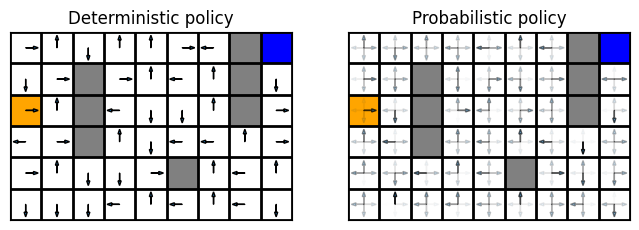

In [2]:
gw = GW.Sutton_Barto_Example8_1()
policy1 = RL_utils.generate_random_policy(gw, deterministic=True)
policy2 = RL_utils.generate_random_policy(gw, deterministic=False)

gw.plot(plots=[('policy', { 'policy': policy1, 'title': "Deterministic policy" }), 
               ('policy', { 'policy': policy2, 'title': "Probabilistic policy" })])

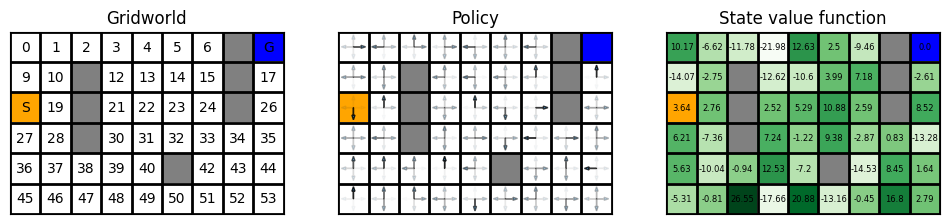

In [3]:
policy = RL_utils.generate_random_policy(gw, deterministic=False)
V = RL_utils.generate_random_v(gw)
gw.plot_overview(V, policy)

### Off-policy Monte Carlo with Equiprobable Behavior Policy

In [29]:
def greedy_action(Q, s):
    max_val = np.max(Q[s])
    best_actions = np.flatnonzero(Q[s] == max_val)
    return np.random.choice(best_actions)

def greedy_policy(gridworld, Q):

    policy = np.zeros_like(Q)
    states_, actions_ = np.nonzero((Q.T == np.max(Q, axis=1)).T)
    for s in np.arange(gridworld.nstates):

                policy[s, np.random.choice(actions_[states_ == s])] = 1.0
                
    return policy

def train(gridworld, episodes=10, gamma=0.95):

    Q = np.zeros((gridworld.nstates, len(gridworld.actions)))
    C = np.zeros_like(Q, dtype=int)
    steps_per_episode = []

    for i in range(episodes):

        # generate episode
        s = gridworld.initial_state

        s_episode = np.array([s])
        a_idx_episode = np.array([], dtype=int)
        r_episode = np.array([])

        steps = 0
        while not s == gridworld.terminal_state:

            # action selection with equiprobable behavior policy
            a_idx = np.random.choice(len(gridworld.actions))
            a = gridworld.actions[a_idx]

            # interaction with environment
            s_prime, r = gridworld.interact(s, a)

            s_episode = np.append(s_episode, s_prime)
            a_idx_episode = np.append(a_idx_episode, a_idx)
            r_episode = np.append(r_episode, r)

            s = s_prime
            steps += 1
        
        steps_per_episode.append(steps)
        
        # updates
        T = len(r_episode)
        G = 0
        W = 1
        for t in np.arange(T-1, -1, -1):
            G = gamma * G + r_episode[t]

            s_t = s_episode[t]
            a_t = a_idx_episode[t]

            a_greedy = greedy_action(Q, s_t)

            if a_t != a_greedy:
                break
            
            mu = 1.0 / len(gridworld.actions)
            W *= 1 / mu
      
            C[s_t][a_t] += W
            Q[s_t][a_t] = Q[s_t][a_t] + (W / C[s_t][a_t]) * (G - Q[s_t][a_t])
            
    return Q, greedy_policy(gridworld, Q), steps_per_episode

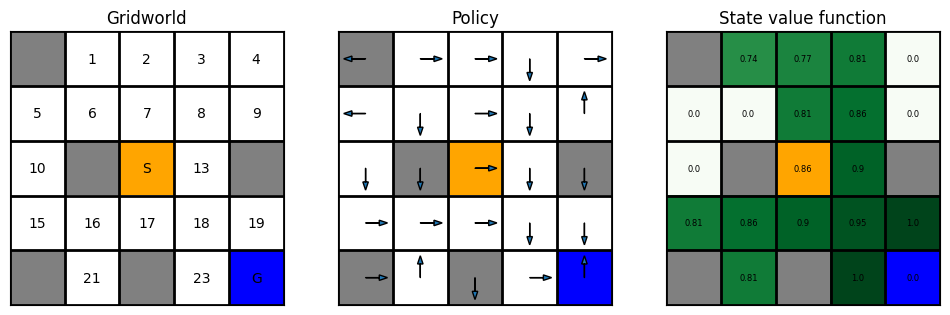

In [69]:
gw = GW.Sutton_Barto_Example8_1(grid_size=(5,5), nwalls=5)
Q, policy, steps_per_episode = train(gw, episodes=1000)
V = np.sum(policy * Q, axis=1)

gw.plot_overview(V, policy)

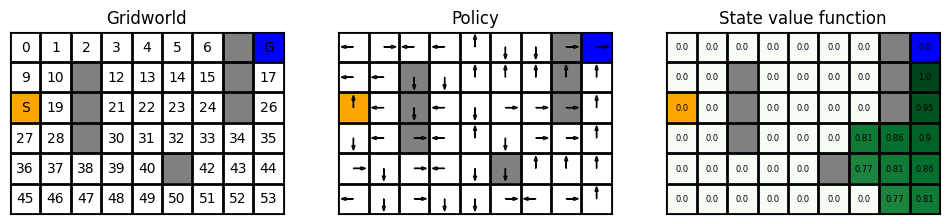

In [32]:
gw = GW.Sutton_Barto_Example8_1()
Q, policy, steps_per_episode_ = train(gw, episodes=1000)
V = np.sum(policy * Q, axis=1)

gw.plot_overview(V, policy)

### Off-policy Monte Carlo with  Probabilities ε-soft Behavior Policy

In [33]:
def greedy_policy(gridworld, Q):

    policy = np.zeros_like(Q)
    states_, actions_ = np.nonzero((Q.T == np.max(Q, axis=1)).T)
    for s in np.arange(gridworld.nstates):

                policy[s, np.random.choice(actions_[states_ == s])] = 1.0
                
    return policy

def greedy_action(Q, s):
    max_val = np.max(Q[s])
    best_actions = np.flatnonzero(Q[s] == max_val)
    return np.random.choice(best_actions)

def train1(gridworld, episodes=10, gamma=0.95, epsilon=0.1):

    Q = np.zeros((gridworld.nstates, len(gridworld.actions)))
    C = np.zeros_like(Q, dtype=float)
    N_a = len(gridworld.actions)

    steps_per_episode = []
    for i in range(episodes):

        # generate episode
        s = gridworld.initial_state

        s_episode = np.array([s])
        a_idx_episode = np.array([], dtype=int)
        r_episode = np.array([])

        steps = 0
        while not s == gridworld.terminal_state:

            # action selection with epsilon soft action selection
            if np.random.rand() < epsilon:
                a_idx = np.random.choice(N_a)
            else:
                 a_idx = greedy_action(Q, s)
            
            a = gridworld.actions[a_idx]

            # interaction with environment
            s_prime, r = gridworld.interact(s, a)

            s_episode = np.append(s_episode, s_prime)
            a_idx_episode = np.append(a_idx_episode, a_idx)
            r_episode = np.append(r_episode, r)

            s = s_prime
            steps += 1
        steps_per_episode.append(steps)
        # updates
        T = len(r_episode)
        G = 0
        W = 1
        for t in np.arange(T-1, -1, -1):
            G = gamma * G + r_episode[t]

            s_t = s_episode[t]
            a_t = a_idx_episode[t]

            C[s_t][a_t] += W
            Q[s_t][a_t] += (W / C[s_t][a_t]) * (G - Q[s_t][a_t])

            a_greedy = greedy_action(Q, s_t)
            if a_t != a_greedy:
                break

            prob_mu = (1 - epsilon) + epsilon / N_a
            W = W * (1 / prob_mu)
      

    return Q, greedy_policy(gridworld, Q), steps_per_episode

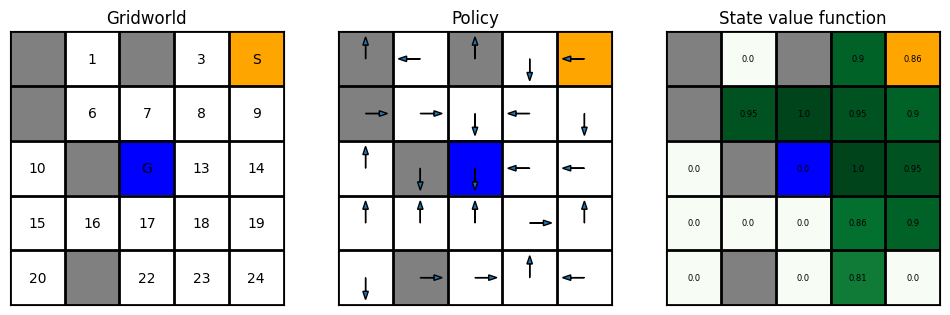

In [61]:
gw = GW.Sutton_Barto_Example8_1(grid_size=(5,5), nwalls=5)
Q, policy, steps_per_episode = train1(gw, episodes=1000)
V = np.sum(policy * Q, axis=1)

gw.plot_overview(V, policy)

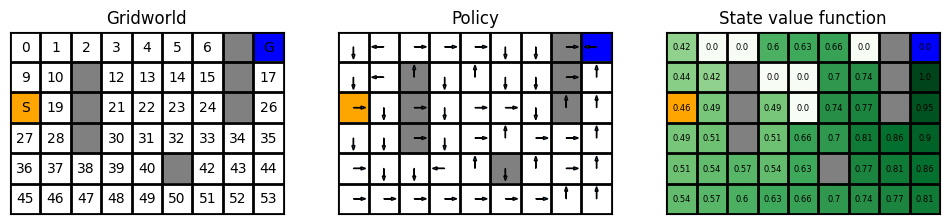

In [62]:
gw = GW.Sutton_Barto_Example8_1()
Q, policy, steps_per_episode_ = train1(gw, episodes=1000)
V = np.sum(policy * Q, axis=1)

gw.plot_overview(V, policy)

In [ ]:
def average_runs(train_fn, runs=10, episodes=500):

    all_runs = []

    for _ in range(runs):
        gw = GW.Sutton_Barto_Example8_1(grid_size=(5,5), nwalls=5)
        _, _, steps = train_fn(gw, episodes=episodes)
        all_runs.append(steps)

    return np.mean(all_runs, axis=0)

episodes = 500

equi_avg = average_runs(train, episodes=episodes)
eps_avg = average_runs(train1, episodes=episodes)

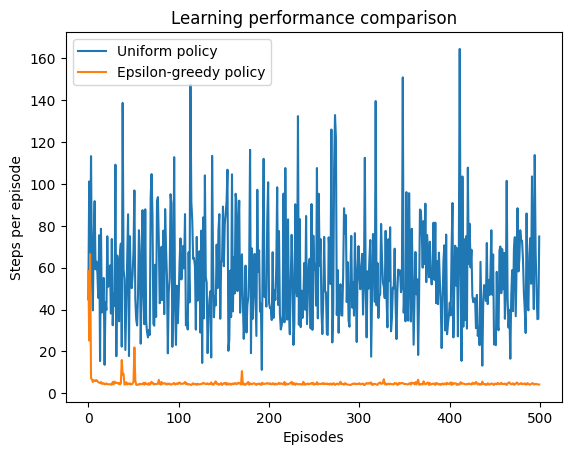

In [ ]:
plt.plot(equi_avg, label="Uniform policy")
plt.plot(eps_avg, label="Epsilon-greedy policy")

plt.xlabel("Episodes")
plt.ylabel("Steps per episode")
plt.title("Learning performance comparison")
plt.legend()
plt.show()